# Semantic Embedding Analysis

## Objective

This notebook explores whether semantic embedding models can better represent therapeutic and non-therapeutic passages in Frankenstein.

Unlike TF-IDF, which relies on word frequency, sentence embeddings capture contextual meaning and relationships between concepts.

The goal is to compare semantic representations with classical machine learning approaches.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving frankenstein_training_dataset_v2.csv to frankenstein_training_dataset_v2.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "frankenstein_training_dataset_v2.csv"
)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (39, 7)


,passage_id,text,therapeutic_label,mechanism,intensity,annotator_notes,keyword_score
0,10,This appearance excited our unqualified wonder...,0.0,NaN,0.0,The passage describes curiosity and wonder dur...,NaN
1,16,Will you smile at the enthusiasm I express con...,1.0,Narrative Reconstruction,3.0,The passage introduces Victor's suffering and ...,NaN
2,26,I feel exquisite pleasure in dwelling on the r...,1.0,Narrative Reconstruction,4.0,The passage represents autobiographical reflec...,NaN
3,67,"“She most of all,” said Ernest, “requires cons...",0.0,NaN,0.0,"The passage describes grief, guilt, and emotio...",NaN
4,127,“I knocked. ‘Who is there?’ said the old man. ...,0.0,NaN,0.0,The passage represents a compassionate social ...,NaN


In [3]:
!pip install sentence-transformers

In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully


In [5]:
embeddings = model.encode(
    df["text"].tolist(),
    show_progress_bar=True
)

print("Embedding generation completed")
print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding generation completed
Embedding shape: (39, 384)


## Sentence-BERT Embedding Results

Sentence-BERT was used to convert the 39 Frankenstein passages into semantic vector representations.

Each passage was transformed into a 384-dimensional embedding. Unlike TF-IDF representations, these embeddings capture contextual relationships between words and concepts, allowing analysis beyond individual vocabulary patterns.

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(
    n_components=2,
    random_state=42
)

embedding_2d = pca.fit_transform(
    embeddings
)

print("PCA completed")
print("Reduced shape:", embedding_2d.shape)

PCA completed
Reduced shape: (39, 2)


In [8]:
embedding_df = pd.DataFrame(
    embedding_2d,
    columns=["PC1", "PC2"]
)

embedding_df["therapeutic_label"] = (
    df["therapeutic_label"].values
)

embedding_df["passage_id"] = (
    df["passage_id"].values
)

embedding_df.head()

,PC1,PC2,therapeutic_label,passage_id
0,0.351400,-0.491839,0.0,10
1,0.016081,0.237238,1.0,16
2,0.274395,0.192235,1.0,26
3,-0.362528,-0.266541,0.0,67
4,-0.106767,-0.005878,0.0,127


## Semantic Space Visualization

Principal Component Analysis (PCA) was applied to reduce Sentence-BERT embeddings into two dimensions. The visualization examines whether therapeutic and non-therapeutic passages form distinguishable semantic clusters.

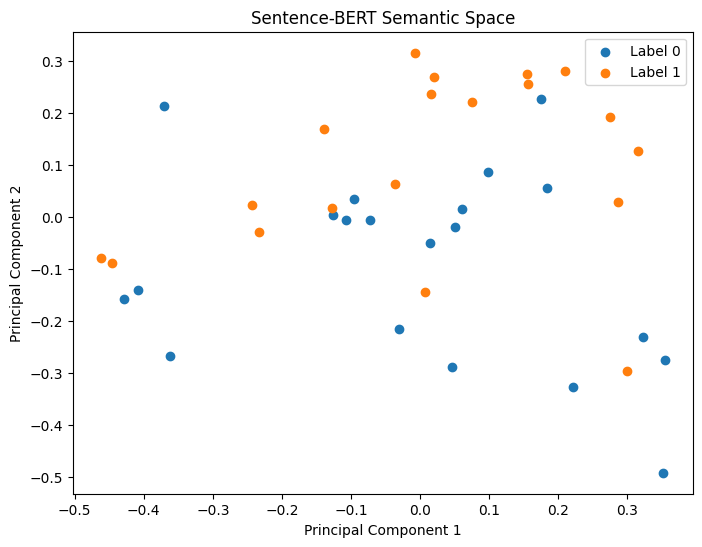

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for label in [0.0, 1.0]:
    subset = embedding_df[
        embedding_df["therapeutic_label"] == label
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Label {int(label)}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Sentence-BERT Semantic Space")
plt.legend()
plt.show()

## Semantic Space Visualization Findings

PCA visualization of Sentence-BERT embeddings shows partial overlap between therapeutic and non-therapeutic passages.

Unlike simple keyword-based classification, semantic embeddings represent broader contextual relationships. The overlap between categories reflects the complexity of literary therapeutic representation, where similar emotional themes may function differently depending on narrative context.

The visualization suggests that therapeutic meaning in Frankenstein exists on a continuum rather than as a purely separated binary category.

In [10]:
from sklearn.model_selection import train_test_split

X_embed = embeddings
y = df["therapeutic_label"]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_embed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Embedding split completed")
print("Training:", X_train_e.shape)
print("Testing:", X_test_e.shape)

Embedding split completed
Training: (31, 384)
Testing: (8, 384)


## Sentence-BERT Embedding Split

The semantic embeddings were divided into training and testing subsets using stratified sampling.

The training set contains 31 passages represented as 384-dimensional semantic vectors, while the testing set contains 8 passages. Class proportions were preserved to allow comparison with previous TF-IDF based experiments.

In [11]:
from sklearn.linear_model import LogisticRegression

embedding_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

embedding_model.fit(
    X_train_e,
    y_train_e
)

print("Embedding Logistic Regression trained successfully")

Embedding Logistic Regression trained successfully


In [12]:
embed_pred = embedding_model.predict(
    X_test_e
)

print("Predicted:", embed_pred)
print("Actual:", y_test_e.values)

Predicted: [0. 0. 0. 1. 0. 1. 0. 1.]
Actual: [0. 0. 1. 1. 0. 1. 0. 1.]


In [13]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print(
    "Sentence-BERT Logistic Regression Accuracy:",
    accuracy_score(y_test_e, embed_pred)
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(y_test_e, embed_pred)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_e,
        embed_pred,
        zero_division=0
    )
)

Sentence-BERT Logistic Regression Accuracy: 0.875

Confusion Matrix:
[[4 0]
 [1 3]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         4
         1.0       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



## Sentence-BERT Classification Results

A Logistic Regression classifier trained on Sentence-BERT embeddings achieved 87.5% accuracy on the test set.

Compared with TF-IDF based Logistic Regression, the semantic embedding approach improved classification performance by capturing contextual relationships beyond individual word frequencies.

The model achieved perfect precision for therapeutic passages, indicating that semantic representations reduce false identification of non-therapeutic passages as therapeutic.

These findings suggest that transformer-based embeddings provide a stronger computational approach for analysing complex literary concepts where meaning depends on narrative context rather than isolated vocabulary.

In [14]:
embedding_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF Logistic Regression",
        "TF-IDF Random Forest",
        "TF-IDF Linear SVM",
        "Sentence-BERT Logistic Regression"
    ],
    "Accuracy": [
        0.75,
        0.50,
        0.75,
        0.875
    ],
    "Therapeutic_Recall": [
        0.75,
        0.25,
        1.00,
        0.75
    ]
})

embedding_comparison.to_csv(
    "tfidf_vs_sentencebert_comparison.csv",
    index=False
)

print("Comparison file saved")

Comparison file saved


In [15]:
from google.colab import files

files.download(
    "tfidf_vs_sentencebert_comparison.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
embedding_error_analysis = pd.DataFrame({
    "passage_id": df.loc[y_test_e.index, "passage_id"].values,
    "text": df.loc[y_test_e.index, "text"].values,
    "actual_label": y_test_e.values,
    "predicted_label": embed_pred
})

embedding_error_analysis["correct"] = (
    embedding_error_analysis["actual_label"]
    ==
    embedding_error_analysis["predicted_label"]
)

embedding_error_analysis

,passage_id,text,actual_label,predicted_label,correct
0,125,"“Several changes, in the meantime, took place ...",0.0,0.0,True
1,151,It was in the latter end of September that I a...,0.0,0.0,True
2,78,"I could not answer. “No, Justine,” said Elizab...",1.0,0.0,False
3,62,Clerval spoke thus as we hurried through the s...,1.0,1.0,True
4,79,And on the morrow Justine died. Elizabeth’s he...,0.0,0.0,True
5,26,I feel exquisite pleasure in dwelling on the r...,1.0,1.0,True
6,81,"This advice, although good, was totally inappl...",0.0,0.0,True
7,16,Will you smile at the enthusiasm I express con...,1.0,1.0,True


In [17]:
sentencebert_errors = embedding_error_analysis[
    embedding_error_analysis["correct"] == False
]

sentencebert_errors

,passage_id,text,actual_label,predicted_label,correct
2,78,"I could not answer. “No, Justine,” said Elizab...",1.0,0.0,False


## Sentence-BERT Error Analysis Findings

The Sentence-BERT classifier produced only one misclassification among the test passages. Passage 78 was classified as non-therapeutic despite receiving a therapeutic annotation from human analysis.

The model captured the semantic presence of suffering, grief, and loss but failed to identify the therapeutic dimension created through compassion, emotional support, and recognition of innocence.

This error demonstrates that semantic embeddings provide improved contextual representation compared with TF-IDF methods, but literary therapeutic interpretation remains dependent on understanding narrative function and humanistic context.

In [18]:
embedding_error_analysis.to_csv(
    "sentencebert_error_analysis.csv",
    index=False
)

print("Sentence-BERT error analysis saved")

Sentence-BERT error analysis saved


In [19]:
from google.colab import files

files.download(
    "sentencebert_error_analysis.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>